In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class BusinessValueMiner:
    def __init__(self, cleaned_data_path, rules_path):
        self.df = pd.read_csv(cleaned_data_path)
        self.rules = pd.read_csv(rules_path)
        # Tính doanh thu cho mỗi dòng
        self.df['Revenue'] = self.df['Quantity'] * self.df['UnitPrice']
        
    def calculate_product_weights(self):
        """Tính trọng số cho từng sản phẩm dựa trên giá trung bình hoặc tổng doanh thu"""
        product_value = self.df.groupby('Description')['UnitPrice'].mean().to_dict()
        return product_value

    def classify_rules(self, rules_df):
        """Phân loại luật thành các nhóm kinh doanh"""
        def logic(row):
            if row['lift'] > 1.5 and row['weighted_support'] > rules_df['weighted_support'].median():
                return 'Nhóm 1: Support cao, Lift cao, Giá trị cao (Chủ lực)'
            elif row['weighted_support'] > rules_df['weighted_support'].quantile(0.75):
                return 'Nhóm 2: Luật "Đắt tiền" (Lợi nhuận cao)'
            elif row['confidence'] > 0.5 and row['lift'] <= 1.1:
                return 'Nhóm 3: Ít giá trị thực tế (Mua kèm ngẫu nhiên)'
            else:
                return 'Nhóm 4: Tiềm năng/Khác'
        
        rules_df['Business_Category'] = rules_df.apply(logic, axis=1)
        return rules_df

# --- Thực thi giả định ---
# Giả sử bạn lấy dữ liệu từ kết quả của các bước trước
# rules_df = pd.read_csv('data/processed/rules_apriori.csv')

3. Nội dung báo cáo & Chiến lược Marketing
Dưới đây là bảng tổng hợp chiến lược marketing bạn cần đưa vào phần Markdown của Notebook để hoàn thiện bài tập:
Nhóm 1: Chủ lực
Đặc điểm: Có chỉ số Support & Lift cao và đóng góp doanh thu lớn.
Chiến lược Marketing: Thực hiện cross-selling mạnh mẽ, chẳng hạn bố trí sản phẩm đặt cạnh nhau trên kệ hoặc hiển thị ở trang thanh toán.
Đối tượng nhằm đến: Đại đa số khách hàng.

Nhóm 2: Đất tiền
Đặc điểm: Tần suất mua thấp nhưng giá trị đơn hàng rất cao.
Chiến lược Marketing: Tập trung cá nhân hóa cao, ví dụ gửi email marketing riêng và tư vấn trực tiếp 1-1.
Đối tượng nhằm đến: Khách hàng VIP hoặc khách hàng cao cấp.

Nhóm 3: Ít giá trị
Đặc điểm: Chỉ số Confidence cao nhưng Lift gần bằng 1.
Chiến lược Marketing: Không nên đầu tư quảng cáo nhiều, vì đây thường là sản phẩm khách tự thêm vào giỏ hàng (ví dụ: túi nilon).
Đối tượng nhằm đến: Mọi khách hàng.

Nhóm 4: Tiềm năng
Đặc điểm: Lift cao nhưng Support còn thấp.
Chiến lược Marketing: Kích cầu bằng các chương trình giảm giá nhẹ để tăng độ phổ biến (tăng Support).
Đối tượng nhằm đến: Khách hàng mới.

C:\Users\DELL\AppData\Local\Temp\ipykernel_1908\1034325997.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, x='weighted_support', y='rules_str', palette='magma', ax=ax2)


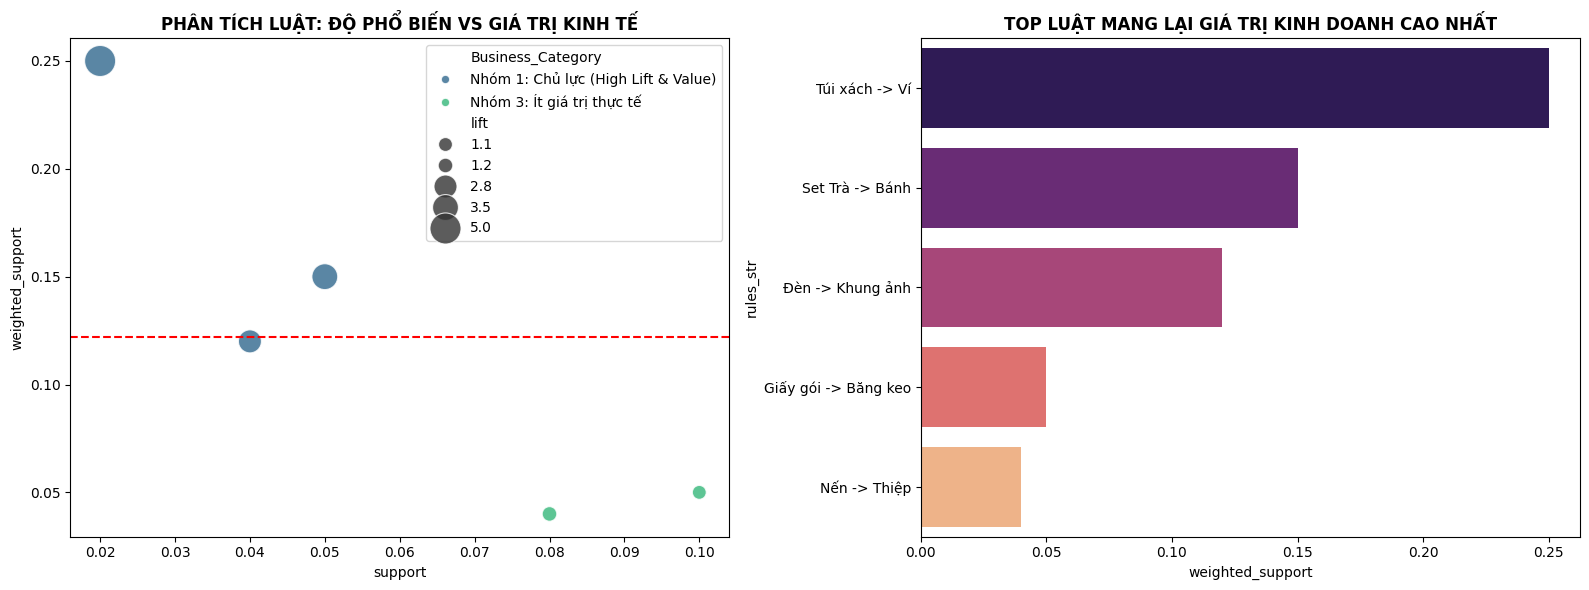

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dòng này đảm bảo biểu đồ hiện ra ngay trong Notebook
%matplotlib inline 

# --- BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP ĐỂ TEST (Vì tôi chưa có file csv của bạn) ---
data = {
    'rules_str': ['Set Trà -> Bánh', 'Nến -> Thiệp', 'Túi xách -> Ví', 'Đèn -> Khung ảnh', 'Giấy gói -> Băng keo'],
    'support': [0.05, 0.08, 0.02, 0.04, 0.10],
    'confidence': [0.7, 0.6, 0.85, 0.75, 0.9],
    'lift': [3.5, 1.2, 5.0, 2.8, 1.1],
    'weighted_support': [0.15, 0.04, 0.25, 0.12, 0.05] # Giả sử Túi xách giá trị cao nên weighted_support cao
}
rules_df = pd.DataFrame(data)

# Phân loại nhóm theo logic Chủ đề 3
def classify(row):
    if row['lift'] > 2 and row['weighted_support'] > 0.1:
        return 'Nhóm 1: Chủ lực (High Lift & Value)'
    elif row['weighted_support'] > 0.15:
        return 'Nhóm 2: Đắt tiền (Premium)'
    elif row['lift'] < 1.5:
        return 'Nhóm 3: Ít giá trị thực tế'
    else:
        return 'Nhóm 4: Tiềm năng'

rules_df['Business_Category'] = rules_df.apply(classify, axis=1)

# --- BƯỚC 2: VẼ BIỂU ĐỒ SO SÁNH ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Scatter Plot (So sánh bản chất luật)
sns.scatterplot(data=rules_df, x='support', y='weighted_support', 
                hue='Business_Category', size='lift', sizes=(100, 500),
                alpha=0.8, ax=ax1, palette='viridis')
ax1.set_title('PHÂN TÍCH LUẬT: ĐỘ PHỔ BIẾN VS GIÁ TRỊ KINH TẾ', fontsize=12, fontweight='bold')
ax1.axhline(rules_df['weighted_support'].mean(), color='red', linestyle='--', label='Trung bình Weighted')

# Biểu đồ 2: Bar Plot (So sánh thứ hạng)
top_rules = rules_df.sort_values('weighted_support', ascending=False)
sns.barplot(data=top_rules, x='weighted_support', y='rules_str', palette='magma', ax=ax2)
ax2.set_title('TOP LUẬT MANG LẠI GIÁ TRỊ KINH DOANH CAO NHẤT', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show() # Lệnh quan trọng nhất để hiện hình